In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

In [ ]:
DATA_PATH = "../data/raw/divar.csv"
df = pd.read_csv(DATA_PATH)

C:\Users\IRANA COMPUTER\AppData\Local\Temp\ipykernel_3212\1138651529.py:2: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


In [3]:
df['has_business_deed'].value_counts(dropna=False)

has_business_deed
NaN      965321
False     17428
True      17251
Name: count, dtype: int64

In [4]:
df[df['cat2_slug'] == 'commercial-sell'].iloc[:, 9: 20]

,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit
13,NaN,NaN,NaN,NaN,مقطوع,8.500000e+08,NaN,NaN,NaN,NaN,NaN
28,NaN,NaN,NaN,NaN,مقطوع,6.600000e+09,NaN,NaN,NaN,NaN,NaN
42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,NaN,NaN,NaN,NaN,مقطوع,1.000000e+02,NaN,NaN,NaN,NaN,NaN
76,NaN,NaN,NaN,NaN,مقطوع,1.500000e+10,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
999795,NaN,NaN,NaN,NaN,مقطوع,1.300000e+09,NaN,NaN,NaN,NaN,NaN
999849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999850,NaN,NaN,NaN,NaN,مقطوع,1.800000e+09,NaN,NaN,NaN,NaN,NaN
999936,NaN,NaN,NaN,NaN,مقطوع,4.400000e+09,NaN,NaN,NaN,NaN,NaN


In [5]:
hyp3_cols = [
    "cat2_slug",
    "price_value",
    "has_business_deed"
]
df_hyp3 = df[hyp3_cols].copy()

In [6]:
df_hyp3 = df_hyp3[df_hyp3['cat2_slug'] == "commercial-sell"].copy()

In [7]:
df_hyp3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38861 entries, 13 to 999938
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cat2_slug          38861 non-null  object 
 1   price_value        32127 non-null  float64
 2   has_business_deed  34679 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.2+ MB


In [8]:
df_hyp3.isnull().sum()

cat2_slug               0
price_value          6734
has_business_deed    4182
dtype: int64

We remove properties where the business deed or the price is missing or invalid.

In [9]:
df_hyp3 = df_hyp3 [
    (df_hyp3['price_value'].notna()) &
    (df_hyp3['price_value'] > 0) &
    (df_hyp3['has_business_deed'].notna())
]
df_hyp3.shape

(28389, 3)

In [10]:
df_hyp3["has_business_deed"].value_counts()

has_business_deed
False    14262
True     14127
Name: count, dtype: int64

In [11]:
df_hyp3.groupby('has_business_deed')['price_value'].describe()

,count,mean,std,min,25%,50%,75%,max
has_business_deed,,,,,,,,
False,14262.0,2.626381e+10,9.379524e+11,1.0,1.000000e+09,2.900000e+09,7.500000e+09,1.000000e+14
True,14127.0,2.763743e+10,5.378173e+11,1.0,1.500000e+09,3.850000e+09,1.000000e+10,4.000000e+13


The variances of the two groups are different.

Since both groups have very high maximum values and very low minimum values, it seems that there are outliers.

Handling outliers

In [12]:
col = 'price_value'
lower = df_hyp3[col].quantile(0.01)
upper = df_hyp3[col].quantile(0.99)
df_hyp3 = df_hyp3[(df_hyp3[col] >= lower) & (df_hyp3[col] <= upper)].copy()

In [13]:
df_hyp3.shape

(27824, 3)

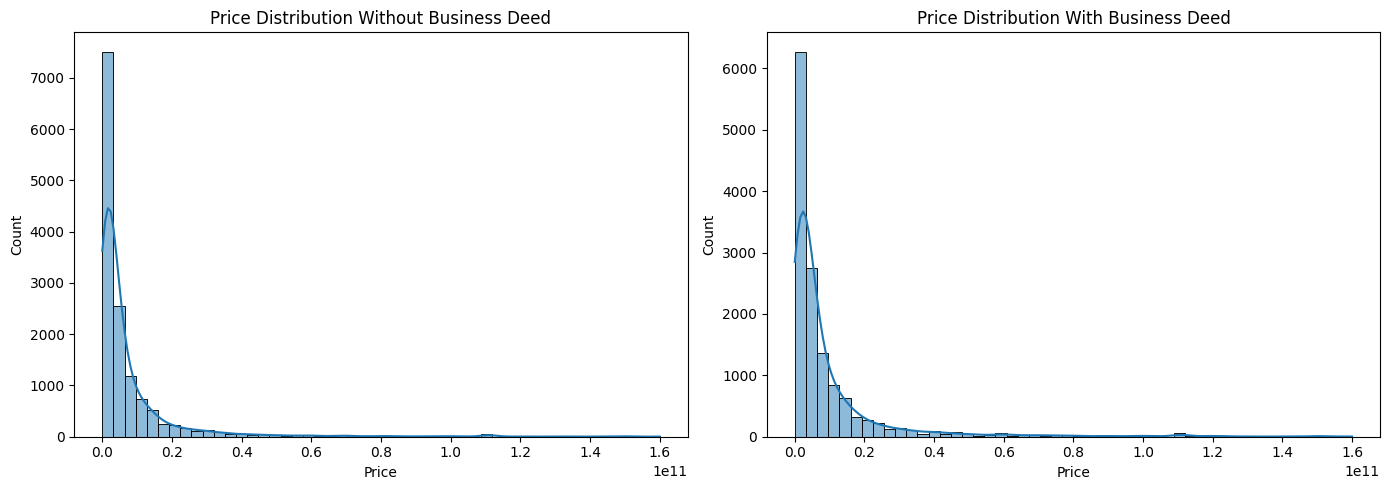

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(
    data=df_hyp3[df_hyp3["has_business_deed"] == False],
    x="price_value",
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Price Distribution Without Business Deed")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")


sns.histplot(
    data=df_hyp3[df_hyp3["has_business_deed"] == True],
    x="price_value",
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Price Distribution With Business Deed")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

as you can see in the histogram plots, the range between the minimum and maximum values is still large. To improve this problem, we use the log of the price value column.

In [16]:
df_hyp3["log_price"] = np.log1p(df_hyp3["price_value"])

In [17]:
df_hyp3[["price_value", "log_price"]].describe()

,price_value,log_price
count,2.782400e+04,27824.000000
mean,8.627609e+09,21.442123
std,1.677654e+10,2.769033
min,4.000000e+02,5.993961
25%,1.250000e+09,20.946409
50%,3.300000e+09,21.917188
75%,8.400000e+09,22.851498
max,1.600000e+11,25.798440


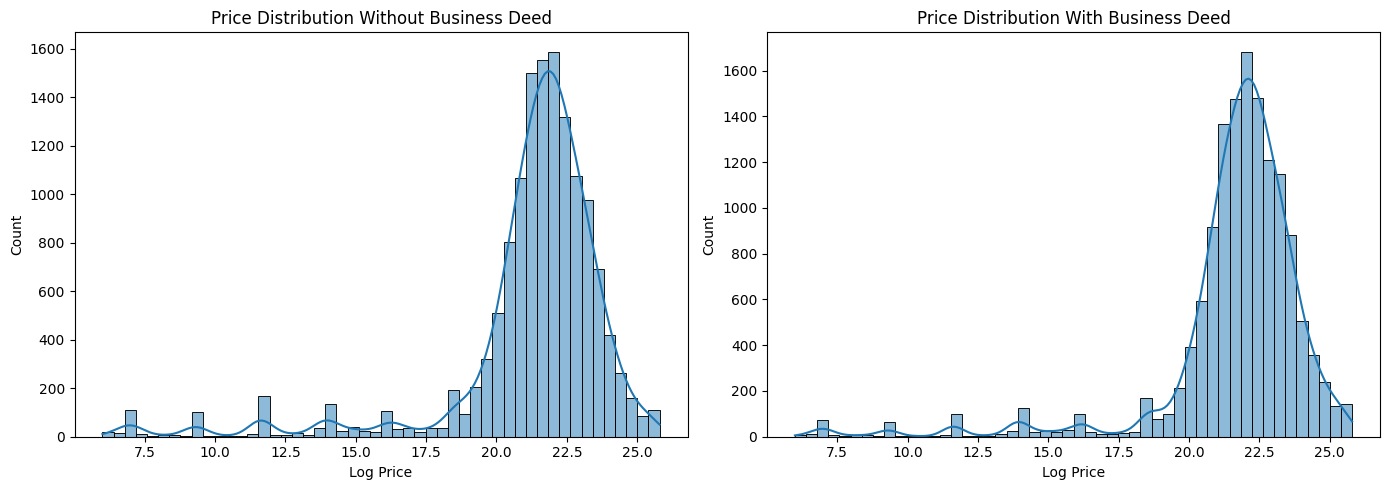

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_hyp3[df_hyp3["has_business_deed"] == False],
    x="log_price",
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Price Distribution Without Business Deed")
axes[0].set_xlabel("Log Price")
axes[0].set_ylabel("Count")


sns.histplot(
    data=df_hyp3[df_hyp3["has_business_deed"] == True],
    x="log_price",
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Price Distribution With Business Deed")
axes[1].set_xlabel("Log Price")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Hypothesis Test

We want to investigate whether there is a statistically significant difference in the mean sale price of commercial properties based on having a business deed.

- **Null Hypothesis (H₀):**  
  There is no statistically significant difference in the mean sale price between commercial properties with a business deed and commercial properties without a business deed.

$$
  H_0: \mu_{\text{with deed}} = \mu_{\text{without deed}}
  $$

- **Alternative Hypothesis (H₁):**  
  There is a statistically significant difference in the mean sale price between commercial properties with a commercial deed and commercial properties without a commercial deed.

  $$
  H_1: \mu_{\text{with deed}} \neq \mu_{\text{without deed}}
  $$

In [21]:
price_without_deed = df_hyp3[df_hyp3["has_business_deed"] == False]["log_price"]
price_with_deed = df_hyp3[df_hyp3["has_business_deed"] == True]["log_price"]

In [26]:
stat_without, p_without = shapiro(price_without_deed)
stat_with, p_with = shapiro(price_with_deed)

alpha = 0.05
print("-" * 50)
print('result : ')
if p_without > alpha:
    print("Without deed group looks normally distributed")
else:
    print("Without deed group does NOT look normally distributed")

if p_with > alpha:
    print("With deed group looks normally distributed")
else:
    print("With deed group does NOT look normally distributed")

--------------------------------------------------
result : 
Without deed group does NOT look normally distributed
With deed group does NOT look normally distributed


The log sale prices in the two groups are not normally distributed. Because of this, an independent t-test is not the best choice.

We have two independent groups:

- commercial properties with a business deed
- commercial properties without a business deed

So, we use the **Mann-Whitney U test**.

This test is useful when the data is not normal. It can compare two independent groups without the normality assumption.

In [27]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(price_with_deed, price_without_deed, alternative="two-sided")

In [28]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference between the two groups.")
else:
    print("Fail to reject H0: There is not enough evidence to show a statistically significant difference.")

Reject H0: There is a statistically significant difference between the two groups.


so the H0 is rejected.

This means that there is a significant difference in log sale prices between commercial properties with a business deed and commercial properties without a business deed.

Therefore, having a business deed may be related to the sale price of commercial properties.